In [1]:
# https://youtu.be/L5iV5BHkMzM
"""
Mitochondria semantic segmentation using U-net, Attention Unet and Att Res Unet

Author: Dr. Sreenivas Bhattiprolu

Dataset from: https://www.epfl.ch/labs/cvlab/data/data-em/
Images and masks are divided into patches of 256x256. 
"""

'\nMitochondria semantic segmentation using U-net, Attention Unet and Att Res Unet\n\nAuthor: Dr. Sreenivas Bhattiprolu\n\nDataset from: https://www.epfl.ch/labs/cvlab/data/data-em/\nImages and masks are divided into patches of 256x256. \n'

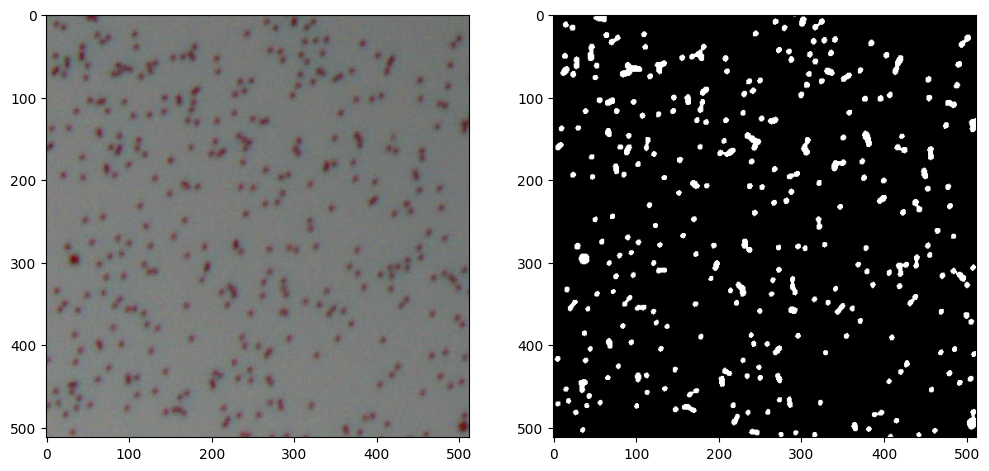

In [5]:
import os
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from datetime import datetime 
import cv2
from PIL import Image
from tensorflow.keras import backend, optimizers


image_directory = 'bead_data/images/'
mask_directory = 'bead_data/mask/'


SIZE = 512
image_dataset = []  #Many ways to handle data, you can use pandas. Here, we are using a list format.  
mask_dataset = []  #Place holders to define add labels. We will add 0 to all parasitized images and 1 to uninfected.

images = sorted(os.listdir(image_directory))
for i, image_name in enumerate(images):    #Remember enumerate method adds a counter and returns the enumerate object
    if (image_name.split('.')[1] == 'png'):
        #print(image_directory+image_name)
        image = cv2.imread(image_directory+image_name, 1)
        image = Image.fromarray(image)
        image = image.resize((SIZE, SIZE))
        image_dataset.append(np.array(image))

#Iterate through all images in Uninfected folder, resize to 64 x 64
#Then save into the same numpy array 'dataset' but with label 1

masks = sorted(os.listdir(mask_directory))
for i, image_name in enumerate(masks):
    if (image_name.split('.')[1] == 'png'):
        image = cv2.imread(mask_directory+image_name, 0)
        image = Image.fromarray(image)
        image = image.resize((SIZE, SIZE))
        mask_dataset.append(np.array(image))


#Normalize images
image_dataset = np.array(image_dataset)/255.
#D not normalize masks, just rescale to 0 to 1.
mask_dataset = np.expand_dims((np.array(mask_dataset)),3) /255.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(image_dataset, mask_dataset, test_size = 0.2, random_state = 0)

#Sanity check, view few mages
import random
import numpy as np
image_number = random.randint(0, len(X_train))
#image_number=10
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(np.reshape(X_train[image_number], (SIZE, SIZE, 3)), cmap='gray')
plt.subplot(122)
plt.imshow(np.reshape(y_train[image_number], (SIZE, SIZE)), cmap='gray')
plt.show()

#######################################
#Parameters for model

IMG_HEIGHT = X_train.shape[1]
IMG_WIDTH  = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]
num_labels = 1  #Binary
input_shape = (IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS)
batch_size = 4

#FOCAL LOSS AND DICE METRIC
#Focal loss helps focus more on tough to segment classes.
from focal_loss import BinaryFocalLoss

In [6]:
###############################################################################

#Try various models: Unet, Attention_UNet, and Attention_ResUnet
#Rename original python file from 224_225_226_models.py to models.py
from models import Attention_ResUNet, UNet, Attention_UNet, dice_coef, dice_coef_loss, jacard_coef
unet_model = UNet(input_shape)
att_unet_model = Attention_UNet(input_shape)
att_res_unet_model = Attention_ResUNet(input_shape)

#Xukuan Model Training Params
lr = 5e-3
epochs=200
#batch_size=8 Cannot due to insufficient memory

2025-10-14 09:52:26.054123: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-14 09:52:26.618760: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21144 MB memory:  -> device: 0, name: Quadro RTX 6000, pci bus id: 0000:81:00.0, compute capability: 7.5


Model: "UNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 64  640         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 64  256        ['conv2d[0][0]']                 
 alization)                     )                                                              

In [102]:
'''
UNet
'''
unet_model = UNet(input_shape)
unet_model.compile(optimizer=Adam(lr = lr), loss=BinaryFocalLoss(gamma=2), 
              metrics=['accuracy', jacard_coef])


print(unet_model.summary())

start1 = datetime.now() 
unet_history = unet_model.fit(X_train, y_train, 
                    verbose=1,
                    batch_size = batch_size,
                    validation_data=(X_test, y_test ), 
                    shuffle=False,
                    epochs=epochs)

stop1 = datetime.now()
#Execution time of the model 
execution_time_Unet = stop1-start1
print("UNet execution time is: ", execution_time_Unet)

unet_model.save('bead_UNet_100epochs_B_focal.hdf5')

In [102]:
#____________________________________________
'''
Attention UNet
'''
att_unet_model = Attention_UNet(input_shape)

att_unet_model.compile(optimizer=Adam(lr = lr), loss=BinaryFocalLoss(gamma=2), 
              metrics=['accuracy', jacard_coef])


print(att_unet_model.summary())
start2 = datetime.now() 
att_unet_history = att_unet_model.fit(X_train, y_train, 
                    verbose=1,
                    batch_size = batch_size,
                    validation_data=(X_test, y_test ), 
                    shuffle=False,
                    epochs=epochs)
stop2 = datetime.now()
#Execution time of the model 
execution_time_Att_Unet = stop2-start2
print("Attention UNet execution time is: ", execution_time_Att_Unet)

att_unet_model.save('bead_Attention_UNet_100epochs_B_focal.hdf5')

#___________________________________________
'''
Attention Residual Unet
'''
att_res_unet_model = Attention_ResUNet(input_shape)

att_res_unet_model.compile(optimizer=Adam(lr = lr), loss=BinaryFocalLoss(gamma=2), 
              metrics=['accuracy', jacard_coef])


# att_res_unet_model.compile(optimizer=Adam(lr = 1e-3), loss='binary_crossentropy', 
#               metrics=['accuracy', jacard_coef])

print(att_res_unet_model.summary())


start3 = datetime.now() 
att_res_unet_history = att_res_unet_model.fit(X_train, y_train, 
                    verbose=1,
                    batch_size = batch_size,
                    validation_data=(X_test, y_test ), 
                    shuffle=False,
                    epochs=epochs)
stop3 = datetime.now()

#Execution time of the model 
execution_time_AttResUnet = stop3-start3
print("Attention ResUnet execution time is: ", execution_time_AttResUnet)

att_res_unet_model.save('bead_AttResUnet_100epochs_B_focal.hdf5')

In [2]:
############################################################################
# convert the history.history dict to a pandas DataFrame and save as csv for
# future plotting
import pandas as pd    
unet_history_df = pd.DataFrame(unet_history.history) 
att_unet_history_df = pd.DataFrame(att_unet_history.history) 
att_res_unet_history_df = pd.DataFrame(att_res_unet_history.history) 

with open('unet_history_df.csv', mode='w') as f:
    unet_history_df.to_csv(f)
    
with open('att_unet_history_df.csv', mode='w') as f:
    att_unet_history_df.to_csv(f)

with open('custom_code_att_res_unet_history_df.csv', mode='w') as f:
    att_res_unet_history_df.to_csv(f)    

NameError: name 'unet_history' is not defined

In [93]:
#######################################################################
#Check history plots, one model at a time
#history = unet_history
#history = att_unet_history
history = att_res_unet_history

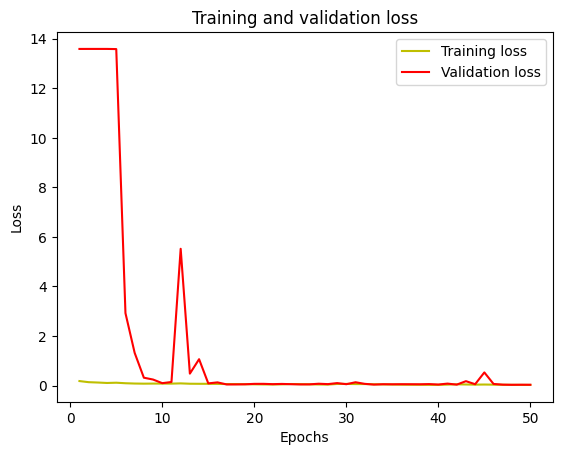

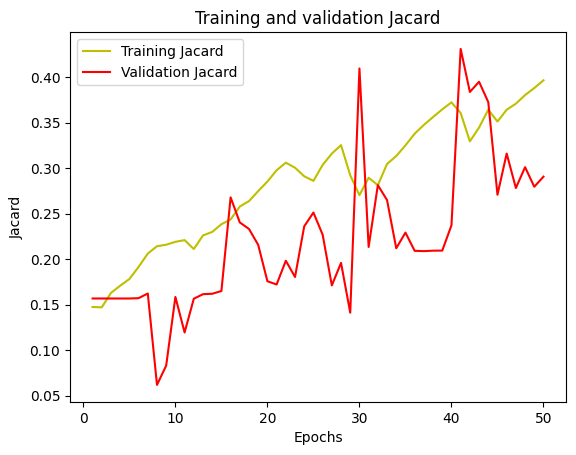

In [47]:
#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['jacard_coef']
#acc = history.history['accuracy']
val_acc = history.history['val_jacard_coef']
#val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training Jacard')
plt.plot(epochs, val_acc, 'r', label='Validation Jacard')
plt.title('Training and validation Jacard')
plt.xlabel('Epochs')
plt.ylabel('Jacard')
plt.legend()
plt.show()

In [8]:
#######################################################



model1 = unet_model
model2 = att_unet_model
model3 = att_res_unet_model

model1_path = "bead_models/bead_UNet_100epochs_B_focal.hdf5"
model2_path = "bead_models/bead_Attention_UNet_100epochs_B_focal.hdf5"
model3_path = "bead_models/bead_AttResUnet_100epochs_B_focal.hdf5"
#Load one model at a time for testing.
model1 = tf.keras.models.load_model(model1_path, compile=False)
model2 = tf.keras.models.load_model(model2_path, compile=False)
model3 = tf.keras.models.load_model(model3_path, compile=False)

In [19]:
import random
from tensorflow.keras.metrics import MeanIoU
import pandas as pd

def plot(model):
    test_img_number = 7#random.randint(0, X_test.shape[0]-1)
    print(test_img_number,X_test.shape[0]-1)
    test_img = X_test[test_img_number]
    ground_truth=y_test[test_img_number]

    test_img_input=np.expand_dims(test_img, 0)
    prediction = (model.predict(test_img_input)[0,:,:,0] > 0.5).astype(np.uint8)

    plt.figure(figsize=(16, 8))
    plt.subplot(231)
    plt.title('Testing Image')
    plt.imshow(test_img, cmap='gray')
    plt.subplot(232)
    plt.title('Testing Label')
    plt.imshow(ground_truth[:,:,0], cmap='gray')
    plt.subplot(233)
    plt.title('Prediction on test image')
    plt.imshow(prediction, cmap='gray')

    plt.show()
    
    n_classes = 2
    IOU_keras = MeanIoU(num_classes=n_classes)  
    IOU_keras.update_state(ground_truth[:,:,0], prediction)
    print("Mean IoU =", IOU_keras.result().numpy())
    IoU_values = []
    for img in range(0, X_test.shape[0]):
        temp_img = X_test[img]
        ground_truth=y_test[img]
        temp_img_input=np.expand_dims(temp_img, 0)
        prediction = (model.predict(temp_img_input)[0,:,:,0] > 0.5).astype(np.uint8)
    
        IoU = MeanIoU(num_classes=n_classes)
        IoU.update_state(ground_truth[:,:,0], prediction)
        IoU = IoU.result().numpy()
        IoU_values.append(IoU)

        print(IoU)
    


    df = pd.DataFrame(IoU_values, columns=["IoU"])
    df = df[df.IoU != 1.0]    
    mean_IoU = df.mean().values
    print("Mean IoU is: ", mean_IoU) 

7 19
1/1 [==============================] - 0s 24ms/step


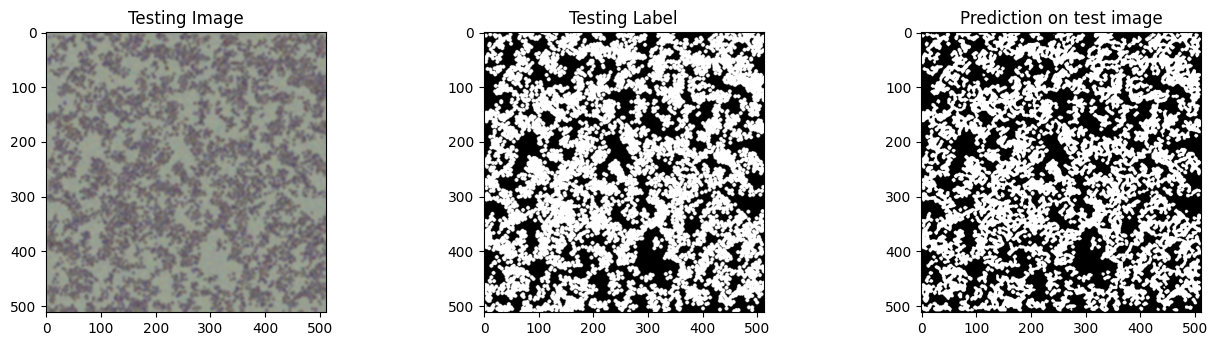

Mean IoU = 0.84575546
1/1 [==============================] - 0s 23ms/step
0.85304534
1/1 [==============================] - 0s 23ms/step
0.79286027
1/1 [==============================] - 0s 23ms/step
0.6893449
1/1 [==============================] - 0s 22ms/step
0.85410506
1/1 [==============================] - 0s 22ms/step
0.8096843
1/1 [==============================] - 0s 22ms/step
0.49926725
1/1 [==============================] - 0s 22ms/step
0.70745134
1/1 [==============================] - 0s 22ms/step
0.84575546
1/1 [==============================] - 0s 21ms/step
0.8358114
1/1 [==============================] - 0s 22ms/step
0.5187529
1/1 [==============================] - 0s 22ms/step
0.7625555
1/1 [==============================] - 0s 21ms/step
0.722098
1/1 [==============================] - 0s 22ms/step
0.8123359
1/1 [==============================] - 0s 22ms/step
0.87290835
1/1 [==============================] - 0s 22ms/step
0.7899094
1/1 [==============================] - 0s 

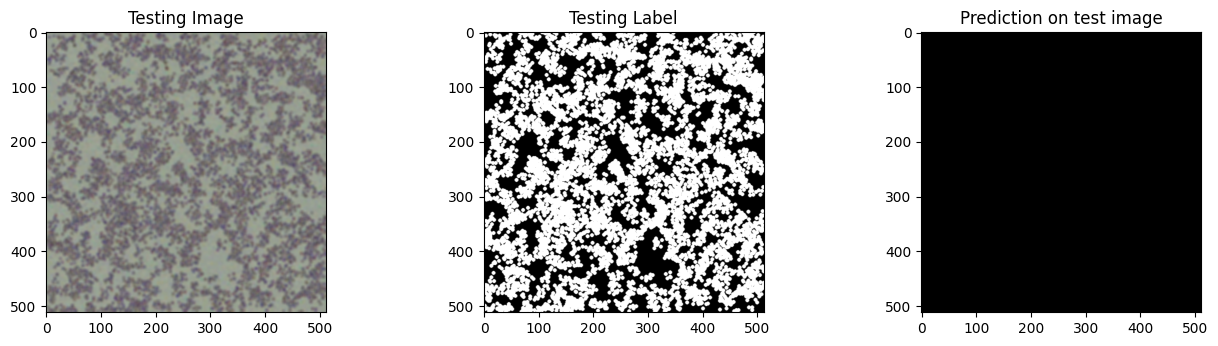

Mean IoU = 0.23777199
1/1 [==============================] - 0s 28ms/step
0.47589767
1/1 [==============================] - 0s 28ms/step
0.23444748
1/1 [==============================] - 0s 28ms/step
0.49965668
1/1 [==============================] - 0s 28ms/step
0.7102019
1/1 [==============================] - 0s 27ms/step
0.49343693
1/1 [==============================] - 0s 28ms/step
0.23968124
1/1 [==============================] - 0s 26ms/step
0.49192044
1/1 [==============================] - 0s 27ms/step
0.23777199
1/1 [==============================] - 0s 29ms/step
0.6645552
1/1 [==============================] - 0s 27ms/step
0.47667977
1/1 [==============================] - 0s 28ms/step
0.5246878
1/1 [==============================] - 0s 27ms/step
0.23457909
1/1 [==============================] - 0s 28ms/step
0.52489793
1/1 [==============================] - 0s 27ms/step
0.6349321
1/1 [==============================] - 0s 27ms/step
0.5539716
1/1 [==============================] -

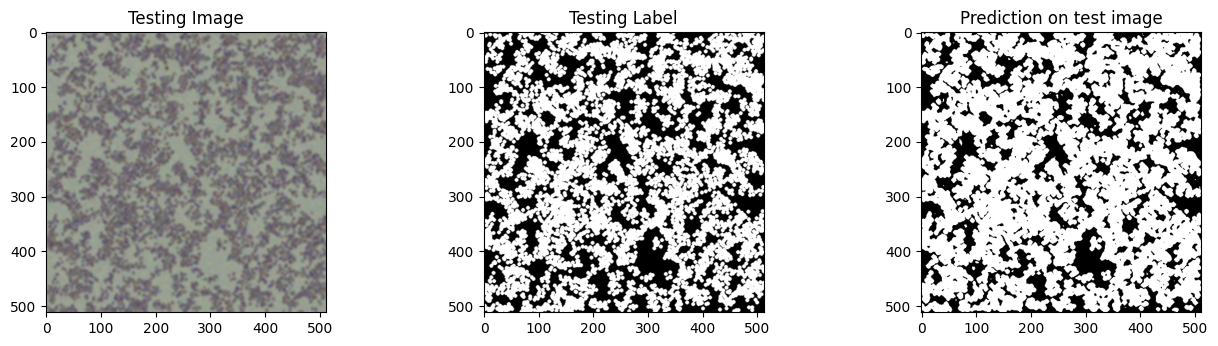

Mean IoU = 0.67872405
1/1 [==============================] - 0s 30ms/step
0.88099533
1/1 [==============================] - 0s 30ms/step
0.6793438
1/1 [==============================] - 0s 29ms/step
0.81202495
1/1 [==============================] - 0s 29ms/step
0.8944317
1/1 [==============================] - 0s 28ms/step
0.8567658
1/1 [==============================] - 0s 27ms/step
0.5408733
1/1 [==============================] - 0s 26ms/step
0.86806864
1/1 [==============================] - 0s 29ms/step
0.67872405
1/1 [==============================] - 0s 27ms/step
0.8558889
1/1 [==============================] - 0s 28ms/step
0.52429605
1/1 [==============================] - 0s 29ms/step
0.82530487
1/1 [==============================] - 0s 29ms/step
0.82677066
1/1 [==============================] - 0s 29ms/step
0.8106302
1/1 [==============================] - 0s 28ms/step
0.89431834
1/1 [==============================] - 0s 28ms/step
0.7930796
1/1 [==============================] - 0

In [20]:
plot(model1)
plot(model2)
plot(model3)

In [56]:
#IoU for a single image
from tensorflow.keras.metrics import MeanIoU

n_classes = 2
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(ground_truth[:,:,0], prediction)
print("Mean IoU =", IOU_keras.result().numpy())


#Calculate IoU for all test images and average
 
import pandas as pd

IoU_values = []
for img in range(0, X_test.shape[0]):
    temp_img = X_test[img]
    ground_truth=y_test[img]
    temp_img_input=np.expand_dims(temp_img, 0)
    prediction = (model.predict(temp_img_input)[0,:,:,0] > 0.5).astype(np.uint8)
    
    IoU = MeanIoU(num_classes=n_classes)
    IoU.update_state(ground_truth[:,:,0], prediction)
    IoU = IoU.result().numpy()
    IoU_values.append(IoU)

    print(IoU)
    


df = pd.DataFrame(IoU_values, columns=["IoU"])
df = df[df.IoU != 1.0]    
mean_IoU = df.mean().values
print("Mean IoU is: ", mean_IoU)    
    

Mean IoU = 0.94987476


2025-10-11 10:30:42.996056: W tensorflow/core/framework/op_kernel.cc:1745] OP_REQUIRES failed at conv_grad_input_ops.cc:92 : INVALID_ARGUMENT: Conv2DSlowBackpropInput: Size of out_backprop doesn't match computed: actual = 32, computed = 16 spatial_dim: 2 input: 16 filter: 3 output: 32 stride: 1 dilation: 1


InvalidArgumentError: Graph execution error:

Detected at node 'AttentionResUNet/conv2d_transpose_4/conv2d_transpose' defined at (most recent call last):
    File "/opt/conda/lib/python3.8/runpy.py", line 194, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/opt/conda/lib/python3.8/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/opt/conda/lib/python3.8/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/opt/conda/lib/python3.8/site-packages/traitlets/config/application.py", line 1043, in launch_instance
      app.start()
    File "/opt/conda/lib/python3.8/site-packages/ipykernel/kernelapp.py", line 712, in start
      self.io_loop.start()
    File "/opt/conda/lib/python3.8/site-packages/tornado/platform/asyncio.py", line 215, in start
      self.asyncio_loop.run_forever()
    File "/opt/conda/lib/python3.8/asyncio/base_events.py", line 570, in run_forever
      self._run_once()